## Resources

Ground Truth Notebook : https://github.com/mrdbourke/pytorch-deep-learning/blob/main/01_pytorch_workflow.ipynb
Book Version of the notebook : https://www.learnpytorch.io/01_pytorch_workflow/
Ask a question : https://github.com/mrdbourke/pytorch-deep-learning/discussions
PythonOOP: https://realpython.com/learning-paths/object-oriented-programming-oop-python/



In [1]:
import torch
from torch import nn ## nn contains all the modules from pytorch
import matplotlib.pyplot as plt

torch.__version__

/home/shelia/anaconda3/envs/tf-gpu/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'1.13.1+cu117'

In [2]:
##Data Preparing and Loading
#Regresssion 

weight=0.7
bias=0.3

#create
start=0
end=1
step=.02
X=torch.arange(start, end,step).unsqueeze(dim=1) #creates a tensor of size 50x1 with values from 0 to 1
y=weight*X+bias
X[:10],y[:10]


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [3]:
X.shape,y.shape

(torch.Size([50, 1]), torch.Size([50, 1]))

In [4]:
##spliting data into training and testing
train_split=int(0.8*len(X))
X_train, y_train=X[:train_split], y[:train_split] #from 0 to train_split - 1
X_test, y_test=X[train_split:], y[train_split:] #from train_split to end
X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([40, 1]),
 torch.Size([40, 1]),
 torch.Size([10, 1]),
 torch.Size([10, 1]))

In [18]:
def plot_prediction(train_data=X_train, train_labels=y_train, ##plots training and testng data and compares predictions
                    test_data=X_test, test_lable=y_test, predictions=None):
    
    plt.figure(figsize=(7,5))
    plt.scatter(train_data, train_labels, c='b', s=4, label="Traing Data")
    plt.scatter(test_data, test_lable, c='r', s=4, label="Testing Data")

    #plotting predictions if provided
    if predictions is not None:
        plt.scatter(test_data, predictions, c='g', s=4, label="Predictions")

    #show the legend
    plt.legend(prop={'size': 8})


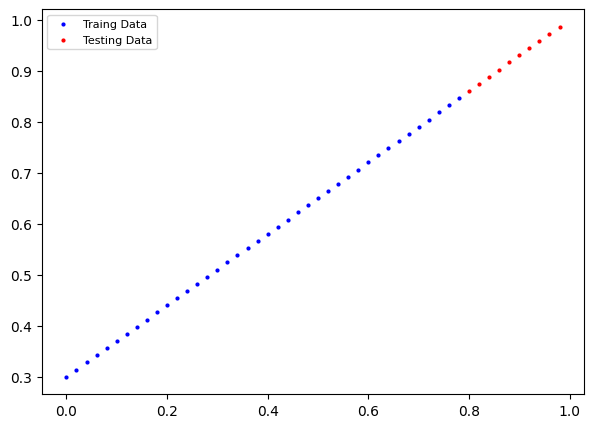

In [19]:
plot_prediction()

# Lets Build a Model now

In [ ]:
#creating a linear regression model class
class LinearRegressionModel(nn.Module): ##nn.Module is the base class for all models in pytorch
    def __init__(self):
        super().__init__()
        self.weights=nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float32))
        self.bias=nn.Parameter(torch.randn(1,
                                           requires_grad=True,
                                           dtype=torch.float32))
        #Forward method for the computation in the model
        def forward(self, x: torch.Tensor)->torch.Tensor:
            return self.weights*x+self.bias